In [20]:
import sys
import os

# 1. Add parent directory to system path
sys.path.append(os.path.abspath('..'))

import preprocessing_old as prep

print("🚀 Starting the unified team preprocessing engine...")

# 2. Use the correct relative paths to the parent folder
train_raw, test_raw = prep.load_data("../spaceship-titanic/train.csv", "../spaceship-titanic/test.csv")
train_clean, test_clean = prep.core_preprocess(train_raw, test_raw)

# Call the encoder customized for MLP
X_mlp, y_mlp, test_mlp, cat_cols, num_cols = prep.encode_for_mlp(train_clean, test_clean)

# Extract the NumPy matrices required by PyTorch
X_train_num = X_mlp[num_cols].values
X_train_cat = X_mlp[cat_cols].values
y = y_mlp.astype(float).values

X_test_num = test_mlp[num_cols].values
X_test_cat = test_mlp[cat_cols].values
test_passenger_ids = test_raw['PassengerId'].values

# Dynamically calculate Embedding dimensions
cat_cardinalities = [int(max(X_mlp[col].max(), test_mlp[col].max()) + 1) for col in cat_cols]
emb_dims = [min(50, (count // 2) + 1) for count in cat_cardinalities]

print(f"✅ Data preparation completed! Numeric features: {len(num_cols)} | Categorical features: {len(cat_cols)}")

🚀 Starting the unified team preprocessing engine...
✅ Data preparation completed! Numeric features: 51 | Categorical features: 5


In [21]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class SpaceshipDataset(Dataset):
    def __init__(self, X_num, X_cat, y=None):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1) if y is not None else None
    def __len__(self): return len(self.X_num)
    def __getitem__(self, idx):
        if self.y is not None: return self.X_num[idx], self.X_cat[idx], self.y[idx]
        return self.X_num[idx], self.X_cat[idx]

class EmbeddingResMLP(nn.Module):
    def __init__(self, num_dims, cat_cardinalities, emb_dims):
        super(EmbeddingResMLP, self).__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(count, dim) for count, dim in zip(cat_cardinalities, emb_dims)])
        input_dim = num_dims + sum(emb_dims)

        self.pre_layer = nn.Sequential(nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU())
        self.res_block = nn.Sequential(
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(0.4852259242406278), # ✨ Optuna best value
            nn.Linear(128, 128), nn.BatchNorm1d(128)
        )
        self.relu = nn.ReLU()
        self.post_layer = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, x_num, x_cat):
        emb_outs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat([x_num] + emb_outs, dim=1)
        x = self.pre_layer(x)
        out = self.res_block(x)
        return self.post_layer(self.relu(out + x))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Model built, using device: {device}")

🔥 Model built, using device: cuda


In [22]:
import numpy as np
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.model_selection import StratifiedKFold

BATCH_SIZE = 128
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
criterion = nn.BCEWithLogitsLoss()
test_loader = DataLoader(SpaceshipDataset(X_test_num, X_test_cat), batch_size=BATCH_SIZE, shuffle=False)
all_fold_probs = []

print("🚀 Starting the 5-Fold training engine...")
for fold, (t_idx, v_idx) in enumerate(skf.split(X_train_num, y)):
    train_loader = DataLoader(SpaceshipDataset(X_train_num[t_idx], X_train_cat[t_idx], y[t_idx]), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(SpaceshipDataset(X_train_num[v_idx], X_train_cat[v_idx], y[v_idx]), batch_size=BATCH_SIZE, shuffle=False)

    model = EmbeddingResMLP(len(num_cols), cat_cardinalities, emb_dims).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=0.00010111139266270338, weight_decay=2.945449919952054e-06)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-8)

    best_acc = 0
    for epoch in range(50):
        model.train()
        for bn, bc, by in train_loader:
            bn, bc, by = bn.to(device), bc.to(device), by.to(device)
            optimizer.zero_grad(); loss = criterion(model(bn, bc), by); loss.backward(); optimizer.step()
        scheduler.step()

        model.eval(); v_ps, v_ts = [], []
        with torch.no_grad():
            for bvn, bvc, bvy in val_loader:
                out = model(bvn.to(device), bvc.to(device))
                v_ps.extend(torch.sigmoid(out).cpu().numpy()); v_ts.extend(bvy.numpy())

        cur_acc = np.mean((np.array(v_ps) > 0.5) == np.array(v_ts))
        if cur_acc > best_acc:
            best_acc = cur_acc; torch.save(model.state_dict(), f'best_model_fold_{fold + 1}.pth')
    print(f"✅ Fold {fold + 1} completed | Peak validation Acc: {best_acc:.4f}")

    # After training the current fold, directly perform inference on the test set
    model.load_state_dict(torch.load(f'best_model_fold_{fold + 1}.pth', weights_only=True))
    model.eval(); fold_probs = []
    with torch.no_grad():
        for bxt_num, bxt_cat in test_loader:
            fold_probs.append(torch.sigmoid(model(bxt_num.to(device), bxt_cat.to(device))).cpu().numpy().flatten())
    all_fold_probs.append(np.concatenate(fold_probs))

blended_probs = np.mean(all_fold_probs, axis=0)
print(f"📊 Base 5-Fold predictions generated!")

🚀 Starting the 5-Fold training engine...
✅ Fold 1 completed | Peak validation Acc: 0.8114
✅ Fold 2 completed | Peak validation Acc: 0.7832
✅ Fold 3 completed | Peak validation Acc: 0.8039
✅ Fold 4 completed | Peak validation Acc: 0.8044
✅ Fold 5 completed | Peak validation Acc: 0.7940
📊 Base 5-Fold predictions generated!


In [23]:
import pandas as pd
import numpy as np

print("🧬 Starting the strict single-pass pseudo-labeling engine...")

# ✨ Strict threshold: prevent overfitting to noisy samples!
confident_mask = (blended_probs > 0.95) | (blended_probs < 0.05)
pseudo_count = np.sum(confident_mask)
print(f"  -> Captured {pseudo_count} extremely high-confidence test set samples!")

if pseudo_count > 0:
    pseudo_y = (blended_probs[confident_mask] > 0.5).astype(float)
    aug_X_num = np.vstack((X_train_num, X_test_num[confident_mask]))
    aug_X_cat = np.vstack((X_train_cat, X_test_cat[confident_mask]))
    aug_y = np.concatenate((y, pseudo_y))

    print(f"  -> Training pool expanded from {len(y)} to {len(aug_y)}! Starting secondary mutation...")
    all_aug_probs = []

    for fold, (t_idx, v_idx) in enumerate(skf.split(aug_X_num, aug_y)):
        aug_train_loader = DataLoader(SpaceshipDataset(aug_X_num[t_idx], aug_X_cat[t_idx], aug_y[t_idx]), batch_size=BATCH_SIZE, shuffle=True)
        aug_val_loader = DataLoader(SpaceshipDataset(aug_X_num[v_idx], aug_X_cat[v_idx], aug_y[v_idx]), batch_size=BATCH_SIZE, shuffle=False)

        model = EmbeddingResMLP(len(num_cols), cat_cardinalities, emb_dims).to(device)
        # ✨ Optuna parameters must also be updated here
        optimizer = optim.AdamW(model.parameters(), lr=0.00010111139266270338, weight_decay=2.945449919952054e-06)
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-8)

        best_p_acc = 0
        for epoch in range(50):
            model.train()
            for bn, bc, by in aug_train_loader:
                bn, bc, by = bn.to(device), bc.to(device), by.to(device)
                optimizer.zero_grad(); loss = criterion(model(bn, bc), by); loss.backward(); optimizer.step()
            scheduler.step()

            model.eval(); v_ps, v_ts = [], []
            with torch.no_grad():
                for bvn, bvc, bvy in aug_val_loader:
                    v_ps.extend(torch.sigmoid(model(bvn.to(device), bvc.to(device))).cpu().numpy()); v_ts.extend(bvy.numpy())

            cur_acc = np.mean((np.array(v_ps) > 0.5) == np.array(v_ts))
            if cur_acc > best_p_acc:
                best_p_acc = cur_acc; torch.save(model.state_dict(), f'pseudo_model_fold_{fold+1}.pth')

        print(f"  ✅ Pseudo-Fold {fold+1} mutation completed | Peak Acc: {best_p_acc:.4f}")

        model.load_state_dict(torch.load(f'pseudo_model_fold_{fold+1}.pth', weights_only=True))
        model.eval(); fold_probs = []
        with torch.no_grad():
            for bxt_num, bxt_cat in test_loader:
                fold_probs.append(torch.sigmoid(model(bxt_num.to(device), bxt_cat.to(device))).cpu().numpy().flatten())
        all_aug_probs.append(np.concatenate(fold_probs))

    pseudo_final_probs = np.mean(all_aug_probs, axis=0)

    # Export the standard submission file
    pd.DataFrame({
        'PassengerId': test_passenger_ids,
        'Transported': (pseudo_final_probs > 0.5).astype(bool)
    }).to_csv("submission_pseudo_label_blend.csv", index=False)

    print("\n✨ Final output: submission_pseudo_label_blend.csv!")

🧬 Starting the strict single-pass pseudo-labeling engine...
  -> Captured 985 extremely high-confidence test set samples!
  -> Training pool expanded from 8693 to 9678! Starting secondary mutation...
  ✅ Pseudo-Fold 1 mutation completed | Peak Acc: 0.8027
  ✅ Pseudo-Fold 2 mutation completed | Peak Acc: 0.8197
  ✅ Pseudo-Fold 3 mutation completed | Peak Acc: 0.8316
  ✅ Pseudo-Fold 4 mutation completed | Peak Acc: 0.8362
  ✅ Pseudo-Fold 5 mutation completed | Peak Acc: 0.8351

✨ Final output: submission_pseudo_label_blend.csv!


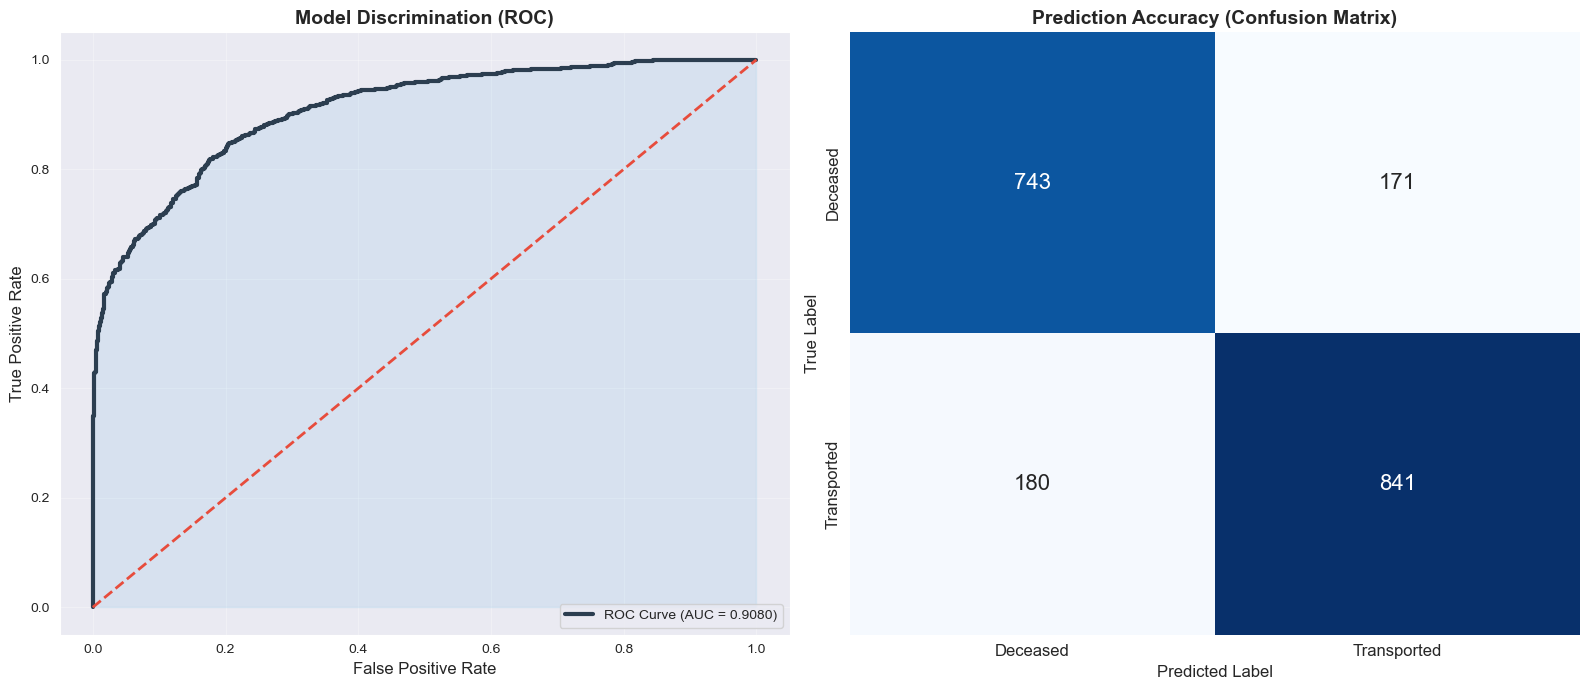

🎯 Final local accuracy (Accuracy): 0.81860
📈 Final area under the curve (AUC Score): 0.90803

📝 Detailed classification report:
              precision    recall  f1-score   support

    Deceased       0.80      0.81      0.81       914
 Transported       0.83      0.82      0.83      1021

    accuracy                           0.82      1935
   macro avg       0.82      0.82      0.82      1935
weighted avg       0.82      0.82      0.82      1935



In [24]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# 1. Plot ROC curve
fpr, tpr, _ = roc_curve(v_ts, v_ps)
roc_auc = auc(fpr, tpr)
ax[0].plot(fpr, tpr, color='#2c3e50', lw=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax[0].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
ax[0].plot([0, 1], [0, 1], color='#e74c3c', lw=2, linestyle='--')
ax[0].set_title('Model Discrimination (ROC)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('False Positive Rate', fontsize=12)
ax[0].set_ylabel('True Positive Rate', fontsize=12)
ax[0].legend(loc="lower right", frameon=True)
ax[0].grid(alpha=0.3)

# 2. Plot confusion matrix
y_pred = (np.array(v_ps) > 0.5).astype(int)
cm = confusion_matrix(v_ts, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            annot_kws={"size": 16}, cbar=False)
ax[1].set_title('Prediction Accuracy (Confusion Matrix)', fontsize=14, fontweight='bold')
ax[1].set_xticklabels(['Deceased', 'Transported'], fontsize=12)
ax[1].set_yticklabels(['Deceased', 'Transported'], fontsize=12)
ax[1].set_xlabel('Predicted Label', fontsize=12)
ax[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

# 3. Print key metrics
print("="*60)
print(f"🎯 Final local accuracy (Accuracy): {np.mean(y_pred == np.array(v_ts)):.5f}")
print(f"📈 Final area under the curve (AUC Score): {roc_auc:.5f}")
print("="*60)
print("\n📝 Detailed classification report:")
print(classification_report(v_ts, y_pred, target_names=['Deceased', 'Transported']))